# Load Model and Data

In [10]:
%load_ext autoreload
%autoreload 2
import torch 
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.models.utils import load_tokenizer
from dreamerv4uwm.models.utils import load_denoiser
# DATA_PATH = "/home/mim-server/datasets/soar_data_sharded"
# DATA_PATH = "/home/mim-server/datasets/Finger/H5/combined"
DATA_PATH = "/media/mim-server/Volume1/lewm/sharded/cube"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resolution = (256, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from hydra import initialize, compose
from omegaconf import OmegaConf
with initialize(version_base=None, config_path="../scripts/config"):
    cfg = compose(config_name="dynamics/lewm-cubes.yaml")

In [24]:
dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/lewm-cubes/joint/500000.pt"
tokenizer_ckpt="/home/mim-server/projects/rooholla/dreamer-v4-draft/checkpoints/tokenizer_ckpts/soar.pt"
cfg.dynamics_ckpt = dynamics_ckpt
cfg.tokenizer_ckpt=tokenizer_ckpt
denoiser = load_denoiser(cfg, device, max_num_forward_steps=1024)
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=1024)
tokenizer = tokenizer.eval().cuda()
denoiser = denoiser.eval().cuda()

In [12]:
import mediapy
from torch.nn.functional import interpolate

dataset = ShardedHDF5Dataset(
        data_dir=DATA_PATH,
        window_size=64,
        stride=32,
        split='train',
        train_fraction=0.9,
        split_seed=123,
    )

# Arbitrary index into that episode
batch = dataset[torch.randint(len(dataset), (1,)).item()]
# imgs = batch["image"][:,[2, 1, 0], :, :]  # (T, C, H, W)
imgs = batch["image"]  # (T, C, H, W)
actions = batch["action"][:,:cfg.denoiser.n_actions]  # (1, T, N_lat, D_lat)
# actions=torch.zeros_like(actions)
imgs = interpolate(imgs, resolution).to(device=device)[None] # resize to tokenizer resolution

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        latents = tokenizer.encode(imgs)
        imgs_recon = tokenizer.decode(latents)

from mediapy import show_video
def plotVideo(video):
    imgs = video.cpu().permute(0,2,3,1).to(torch.float32).numpy()*255
    imgs = imgs.astype('uint8')
    mediapy.show_video(imgs, fps=10)

plotVideo(imgs_recon[0])
plotVideo(imgs[0])

Train split: 45000 windows from 9000 episodes


This browser does not support the video tag.


This browser does not support the video tag.


# Unified Sampler — All 5 UWM Modes

The `unified_flowmatching_sampler` supports all training modes:
- **wm** — World model: given context obs + all actions, predict future obs
- **policy** — Policy: given context obs + context actions, predict future obs + future actions
- **video** — Video prediction: given context obs only (no actions), predict future obs
- **id** — Inverse dynamics: given all obs (clean), predict actions
- **forcing** — Diffusion forcing: given context obs + context actions, predict future obs + future actions

In [13]:
from dreamerv4uwm.sampling import unified_flowmatching_sampler
import matplotlib.pyplot as plt

def plotSnapshots(video, n_frames=5, border_width=2, figsize=None):
    """Plot n_frames evenly-spaced snapshots from a video tensor, separated by black borders.
    
    Args:
        video: (T, C, H, W) tensor with values in [0, 1].
        n_frames: number of frames to sample.
        border_width: width of black separator lines in pixels.
    """
    import numpy as np
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()  # (n, H, W, C)
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, W, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    if figsize is None:
        figsize = (n_frames * 3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

def plotActions(actions, figsize=None):
    import numpy as np
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    # if figsize is None:
    figsize = (3 , 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.plot(act[:, 0], linewidth=3, label=r'$\mathbf{v_x}$')
    ax.plot(act[:, 1], linewidth=3, label=r'$\mathbf{v_y}$')
    ax.set_ylim(-1., 1.)
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(fontsize=16)
    plt.tight_layout()
    plt.show()

In [16]:
num_pred_steps = 32
num_diffusion_steps = 16
T_ctx = 16
latents_ctx = latents[:, :T_ctx, ...].clone()

## 1. World Model (`wm`)
Given context obs and **all** actions (context + future), predict future observations. Actions are treated as clean conditions throughout.

This browser does not support the video tag.


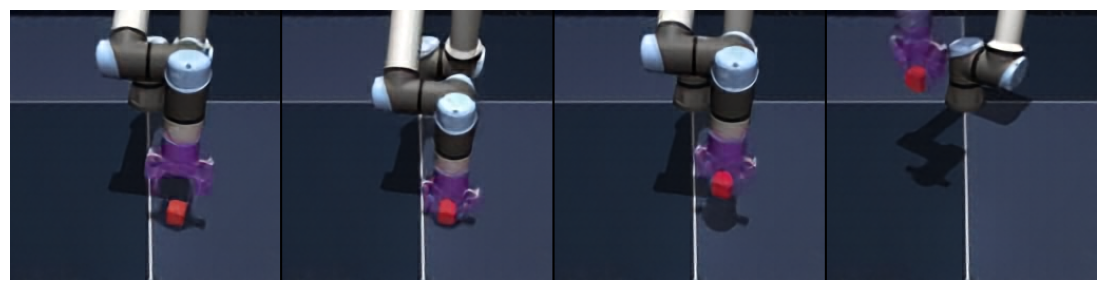

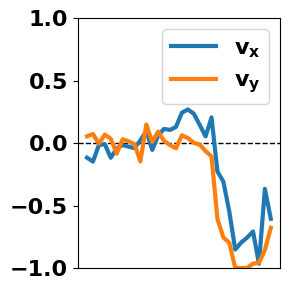

In [17]:
# all_actions_wm = torch.zeros(1, T_ctx + num_pred_steps, 2).to('cuda')  # (1, T_total, n_act)
# all_actions_wm[:, T_ctx:, 0] =  0.  # zero out future actions for worldmodel sampling
# all_actions_wm[:, T_ctx:, 0] =  0.0
# all_actions_wm[:, T_ctx:, :] =  0.0
# all_actions_wm[:, T_ctx:, 0] =  0.0
# all_actions_wm[:, T_ctx:, 1] =  0.0
all_actions_wm = actions.clone()[None].cuda()[:,:T_ctx+num_pred_steps,:]  # (1, T_total, n_act)

# all_actions_wm = torch.from_numpy(pr_act_full)[None].clone()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_wm, _ = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='wm',
        all_actions=all_actions_wm,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
        context_cond_tau=0.8,
    )
    with torch.no_grad():
        img_pred_wm = tokenizer.decode(pred_obs_wm)

plotVideo(img_pred_wm[0].to(torch.float32))
plotSnapshots(img_pred_wm[0].to(torch.float32), n_frames=4)
plotActions(all_actions_wm[0, T_ctx:T_ctx+num_pred_steps])

## 2. Policy (`policy`)
Given context obs + context actions, jointly predict future observations **and** future actions.

This browser does not support the video tag.


This browser does not support the video tag.


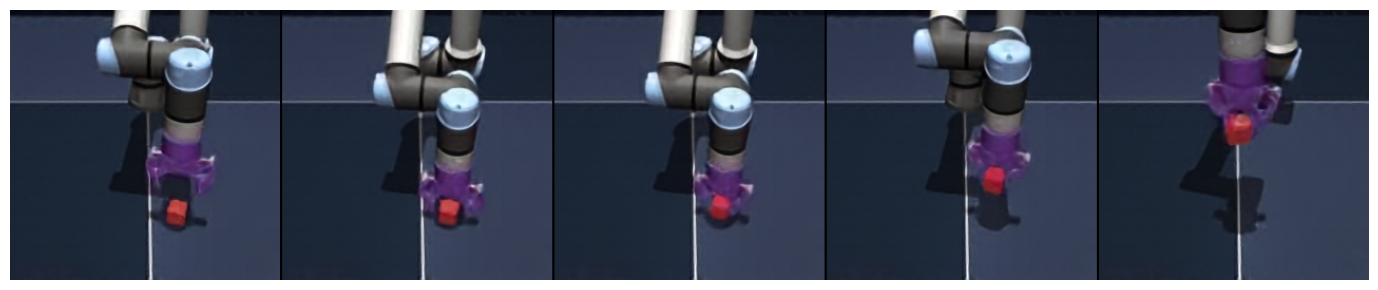

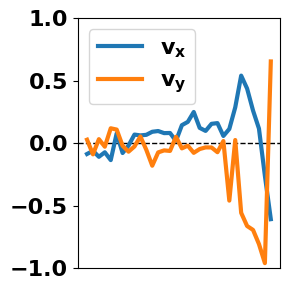

In [18]:
# T_ctx = 4
ctx_actions_policy = actions[:T_ctx][None].cuda()  # (1, T_ctx, n_act)
# ctx_actions_policy+=torch.randn_like(ctx_actions_policy)*0.1  # add noise to context actions for policy sampling

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_pol, pred_act_pol = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='policy',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_pol = tokenizer.decode(pred_obs_pol)

plotVideo(img_pred_pol[0].to(torch.float32))
plotVideo(imgs[0,0:T_ctx].to(torch.float32))
plotSnapshots(img_pred_pol[0].to(torch.float32))
pr_act = pred_act_pol[0].cpu().float().numpy()
plotActions(pr_act)

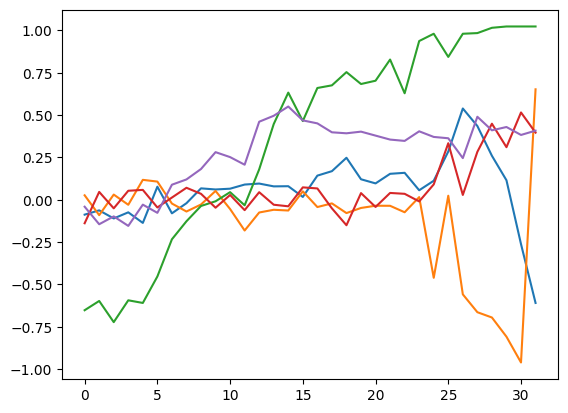

In [19]:
plt.plot(pr_act)

In [20]:
from dreamerv4uwm.sampling import get_noise_index

@torch.no_grad()
def progressive_rolling_sampler(
    denoiser,
    init_latents,           # (B, T_init, N_lat, D_lat) — clean obs context
    init_actions,           # (B, T_init, n_act)        — clean action context
    total_pred_steps,       # frames to emit
    window_size=8,          # F: rolling window size = #steps to fully clean one frame
    context_size=8,         # C: clean prefix kept in front of the window (0 = pure paper algo)
    context_cond_tau=1.0,
    action_noise_std=1.0,
):
    """Progressive autoregressive rolling sampler.

    Adapts 'Progressive Autoregressive Video Diffusion Models' (Xie et al., 2024,
    https://arxiv.org/abs/2410.08151) to the UWM joint obs+action flowmatching
    denoiser. Each main-loop iteration:
        1. All F window frames are denoised by one quantum (dt = 1/F).
        2. The frontmost frame reaches tau=1 (clean) and is emitted.
        3. The window shifts left; a fresh pure-noise frame is appended at the back.
        4. The clean prefix (length C) gains the emitted frame and drops its oldest.

    A short F-1 step warmup grows the window from 1 to F so the staircase noise
    schedule is built in place rather than faked from samples.

    Note: this codebase uses tau=1 == clean, tau=0 == pure noise (opposite of the
    paper). The staircase is expressed in this convention throughout.
    """
    F, C = window_size, context_size
    device = init_latents.device
    dtype  = init_latents.dtype
    B, T_init, N_lat, D_lat = init_latents.shape
    n_act = init_actions.shape[-1]
    init_actions = init_actions.to(device=device, dtype=dtype)

    assert C <= T_init, f"context_size C={C} cannot exceed init context T_init={T_init}"
    N = denoiser.cfg.denoiser.num_noise_levels
    assert N % F == 0, "num_noise_levels must be divisible by window_size for an exact stride"

    stride       = N // F          # quanta advanced per Euler step
    step_size    = 1.0 / F         # Euler dt
    tau_cond_idx = get_noise_index(context_cond_tau, N)

    # always-clean prefix (re-noised to tau_cond on every forward)
    prefix_obs = init_latents[:, -C:].clone() if C > 0 else None
    prefix_act = init_actions[:, -C:].clone() if C > 0 else None

    # rolling window starts with a single pure-noise frame; warmup grows it to F.
    z_obs   = torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype)
    z_act   = action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype)
    tau_idx = torch.zeros((B, 1), dtype=torch.long, device=device)

    def _fresh_noise():
        return (
            torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype),
            action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype),
            torch.zeros((B, 1), dtype=torch.long, device=device),
        )

    pred_obs_buf, pred_act_buf = [], []

    while len(pred_obs_buf) < total_pred_steps:
        cur_F = z_obs.shape[1]

        # ---- assemble input: noised clean prefix + window ----
        if C > 0:
            p_obs_in = (1.0 - context_cond_tau) * torch.randn_like(prefix_obs) + context_cond_tau * prefix_obs
            p_act_in = ((1.0 - context_cond_tau) * action_noise_std * torch.randn_like(prefix_act)
                        + context_cond_tau * prefix_act)
            obs_in = torch.cat([p_obs_in, z_obs], dim=1)
            act_in = torch.cat([p_act_in, z_act], dim=1)
            prefix_sigma = torch.full((B, C), tau_cond_idx, dtype=torch.long, device=device)
            sigma_idx = torch.cat([prefix_sigma, tau_idx], dim=1)
        else:
            obs_in, act_in, sigma_idx = z_obs, z_act, tau_idx

        step_idx_tensor = torch.zeros((B, C + cur_F), dtype=torch.long, device=device)

        z_hat, act_hat, _ = denoiser(
            noisy_act    = act_in,
            noisy_obs    = obs_in,
            obs_sigma_idx= sigma_idx,
            obs_step_idx = step_idx_tensor,
            act_sigma_idx= sigma_idx,
            act_step_idx = step_idx_tensor,
        )
        act_hat = act_hat.squeeze(-2)
        z_hat_w, act_hat_w = z_hat[:, C:], act_hat[:, C:]

        # ---- per-frame Euler step on the window ----
        tau_cont = tau_idx.float() / float(N)              # (B, cur_F)
        denom    = (1.0 - tau_cont).clamp_min(1e-5)         # (B, cur_F)
        z_obs = z_obs + (z_hat_w   - z_obs) / denom[..., None, None] * step_size
        z_act = z_act + (act_hat_w - z_act) / denom[..., None]       * step_size
        tau_idx = tau_idx + stride

        if cur_F < F:
            # warmup: append a fresh noise frame at the back, no emission
            new_o, new_a, new_t = _fresh_noise()
            z_obs   = torch.cat([z_obs,   new_o], dim=1)
            z_act   = torch.cat([z_act,   new_a], dim=1)
            tau_idx = torch.cat([tau_idx, new_t], dim=1)
        else:
            # main: emit front, shift left, append fresh noise at back
            emit_obs, emit_act = z_obs[:, :1], z_act[:, :1]
            pred_obs_buf.append(emit_obs)
            pred_act_buf.append(emit_act)

            new_o, new_a, new_t = _fresh_noise()
            z_obs   = torch.cat([z_obs[:, 1:],   new_o], dim=1)
            z_act   = torch.cat([z_act[:, 1:],   new_a], dim=1)
            tau_idx = torch.cat([tau_idx[:, 1:], new_t], dim=1)

            if C > 0:
                prefix_obs = torch.cat([prefix_obs[:, 1:], emit_obs], dim=1)
                prefix_act = torch.cat([prefix_act[:, 1:], emit_act], dim=1)

    return torch.cat(pred_obs_buf, dim=1), torch.cat(pred_act_buf, dim=1)

This browser does not support the video tag.


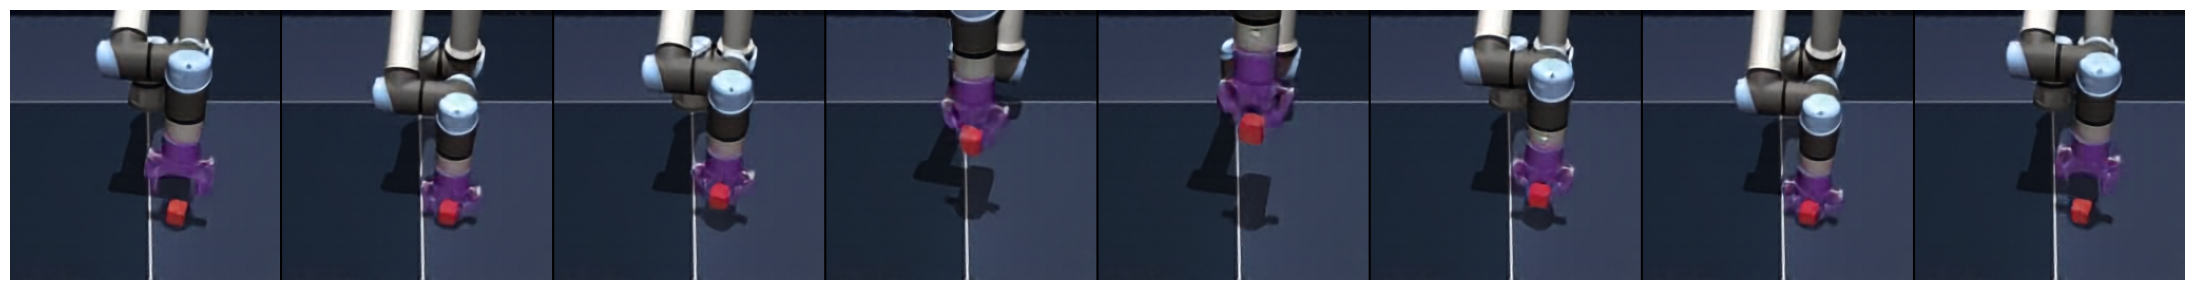

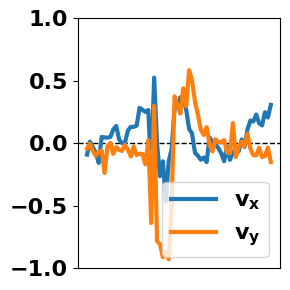

In [28]:
# Progressive autoregressive rollout: per-frame staircase noise schedule.
T_init           = 16       # frames of real history to seed with
total_pred_steps = 64      # frames to emit
window_size      = 16       # F: per-frame staircase depth (= #steps to clean one frame)
context_size     = 16       # C: clean overlap-conditioning prefix

init_latents = latents[:, :T_init, ...].clone()
init_actions = actions[:T_init][None].cuda()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    prog_obs, prog_act = progressive_rolling_sampler(
        denoiser,
        init_latents     = init_latents,
        init_actions     = init_actions,
        total_pred_steps = total_pred_steps,
        window_size      = window_size,
        context_size     = context_size,
    )
    with torch.no_grad():
        prog_imgs = tokenizer.decode(prog_obs)

plotVideo(prog_imgs[0].to(torch.float32))
plotSnapshots(prog_imgs[0].to(torch.float32), n_frames=8)
plotActions(prog_act[0].cpu().float().numpy())

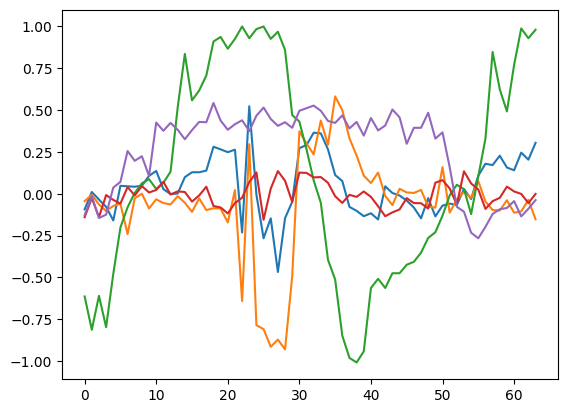

In [29]:
plt.plot(prog_act[0].cpu().float().numpy())

## 3. Video Prediction (`video`)
Given context obs only (no action signal at all), predict future observations. Actions are pure noise throughout — the model must predict the future from visual context alone.

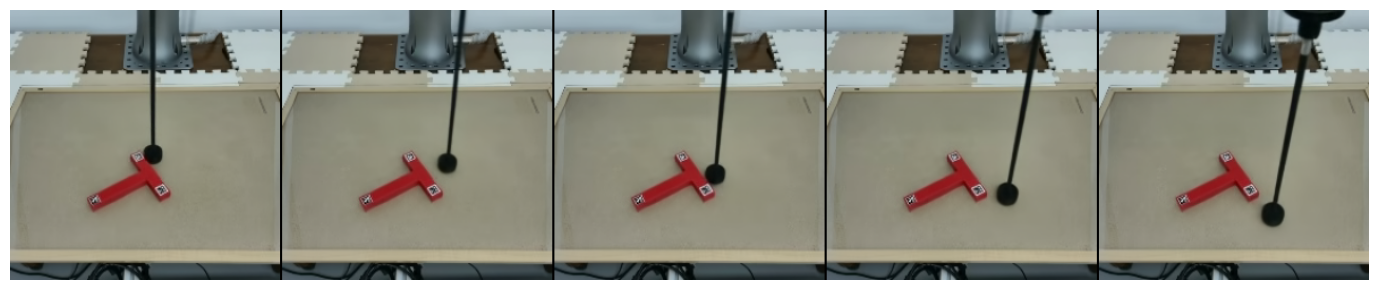

In [164]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_vid, _ = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='video',
        ctx_actions=ctx_actions_policy,  # only used to infer n_act dimension
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_vid = tokenizer.decode(pred_obs_vid)

plotVideo(img_pred_vid[0].to(torch.float32))
plotSnapshots(img_pred_vid[0].to(torch.float32))

## 4. Inverse Dynamics (`id`)
Given **all** observations (context + future, clean), predict actions for all frames. The model infers what actions produced the observed state transitions.

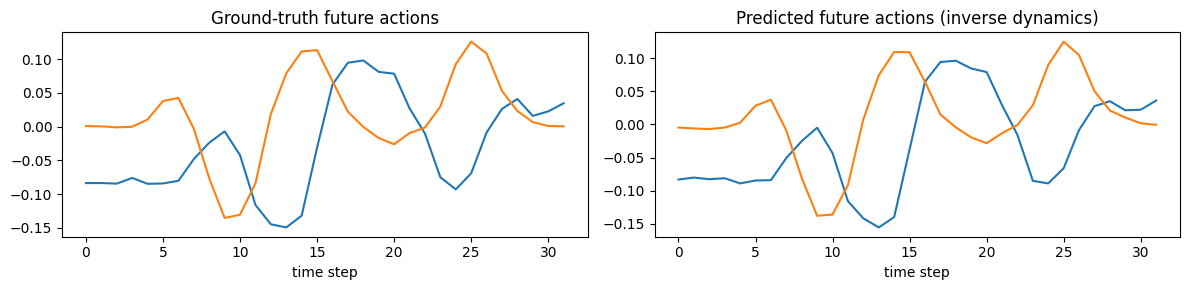

In [98]:
all_latents_id = latents[:, :T_ctx + num_pred_steps, ...]  # (1, T_total, N_lat, D_lat)

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    _, pred_act_id = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='id',
        ctx_actions=ctx_actions_policy,  # used to infer n_act
        all_latents=all_latents_id,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )

# Plot predicted vs ground-truth actions (future portion only)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_id[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (inverse dynamics)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()

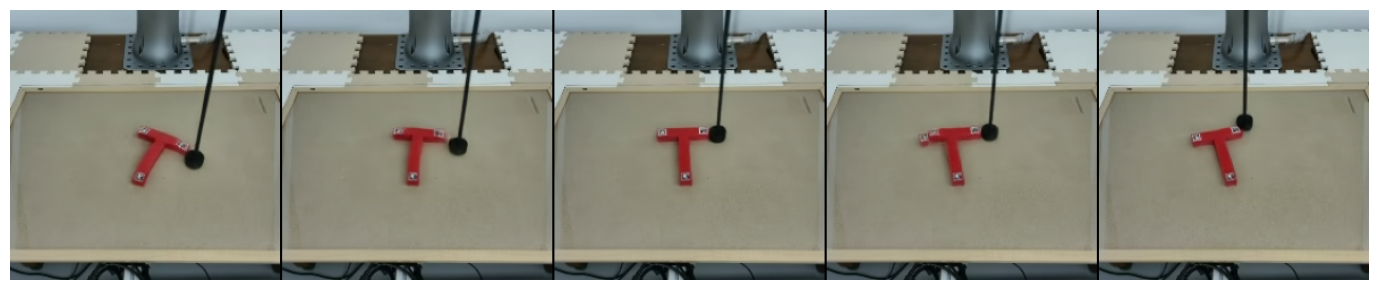

In [83]:
plotSnapshots(img_pred_pol[0].to(torch.float32))

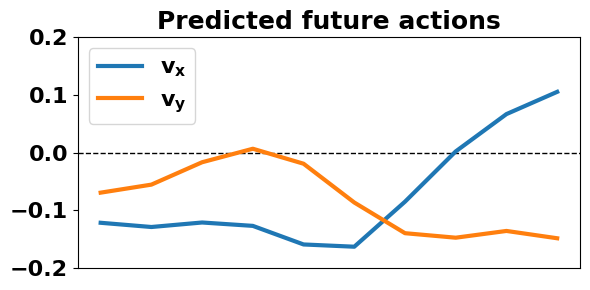

In [91]:
plotActions(pr_act, title="Predicted future actions")

In [ ]:
/scratch/rk4342/projects/dreamerV4-UWM/checkpoints/dynamics/pushT-uwm-all/288240.pt

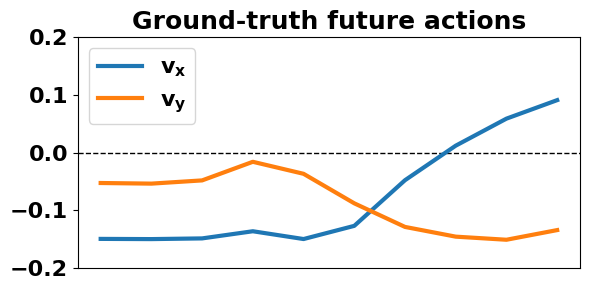

In [92]:
plotActions(gt_act, title="Ground-truth future actions")

## 4b. Action Sampler (`unified_action_sampler`)
Actions for **all** frames (context + horizon) start as pure noise and are jointly denoised. Obs are also denoised everywhere, but context obs starts at a user-chosen noise level (`ctx_obs_init_tau`) while horizon obs starts as pure noise. Each region runs its own Euler integration so it reaches the clean signal in `num_diffusion_steps` steps from its own starting tau.

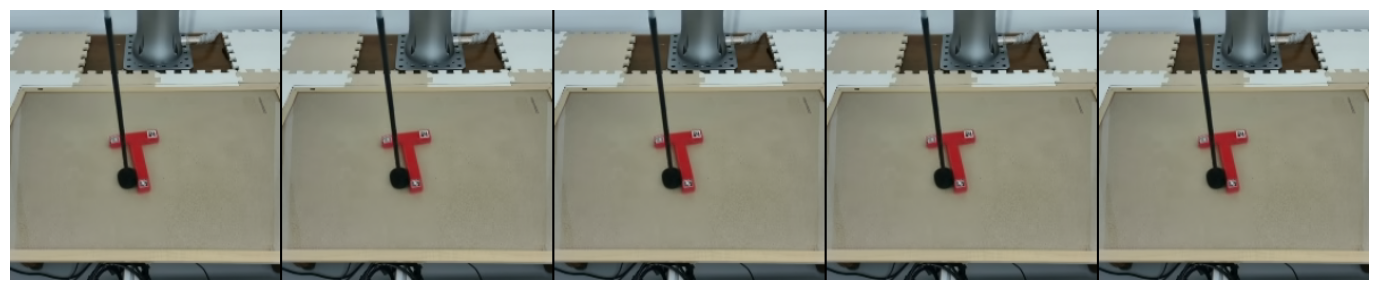

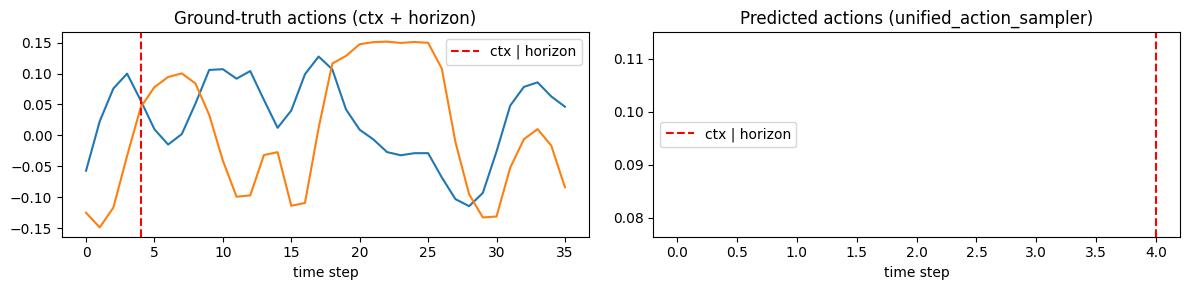

In [126]:
from dreamerv4uwm.sampling import unified_action_sampler

# ctx_obs_init_tau = 0.99  # noise level for context obs at start (0=pure noise, 1=clean)
# tau=0.99
latents_ctx_noisy = latents_ctx.clone()[:, :1, ...]


# # latents_ctx_noisy[:,1:] = (1-tau)*latents_ctx[:,1:] +torch.randn_like(latents_ctx[:,1:])*tau  # add noise to context obs for unified sampling
# latents_ctx_noisy = (1-tau)*latents_ctx +torch.randn_like(latents_ctx_noisy)*tau  # add noise to context obs for unified sampling
# ctx_actions_policy_noisy = (1-ctx_obs_init_tau) * torch.randn_like(ctx_actions_policy) + ctx_obs_init_tau * ctx_actions_policy

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_act, pred_act_act = unified_action_sampler(
        denoiser, torch.randn(1, 1, 256, 32).cuda(),
        ctx_actions=torch.randn(1, 1, 2).cuda(),  # only used to infer n_act
        num_pred_steps=0,
        num_diffusion_steps=8,
        ctx_obs_init_tau=0.0,
    )
    with torch.no_grad():
        img_pred_act = tokenizer.decode(pred_obs_act)

# Visualise the fully denoised obs sequence (context + horizon)
plotVideo(img_pred_act[0].to(torch.float32))
plotSnapshots(img_pred_act[0].to(torch.float32))




# Compare predicted vs ground-truth actions across the FULL sequence
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act_full = actions[:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act_full = pred_act_act[0].cpu().float().numpy()
axes[0].set_title("Ground-truth actions (ctx + horizon)")
axes[0].plot(gt_act_full)
axes[0].axvline(T_ctx, color='red', linestyle='--', label='ctx | horizon')
axes[0].legend()
axes[1].set_title("Predicted actions (unified_action_sampler)")
axes[1].plot(pr_act_full)
axes[1].axvline(T_ctx, color='red', linestyle='--', label='ctx | horizon')
axes[1].legend()
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()

## 4c. Unified Video Sampler (`unified_video_sampler`)
Treats the entire sequence (context + horizon) as one unified noisy latent at a single `current_tau` and denoises every frame uniformly. Actions are pure noise throughout, with tau=0 conditioning fed to the denoiser — the model must reconstruct the video purely from the partially-noised visuals.

This browser does not support the video tag.


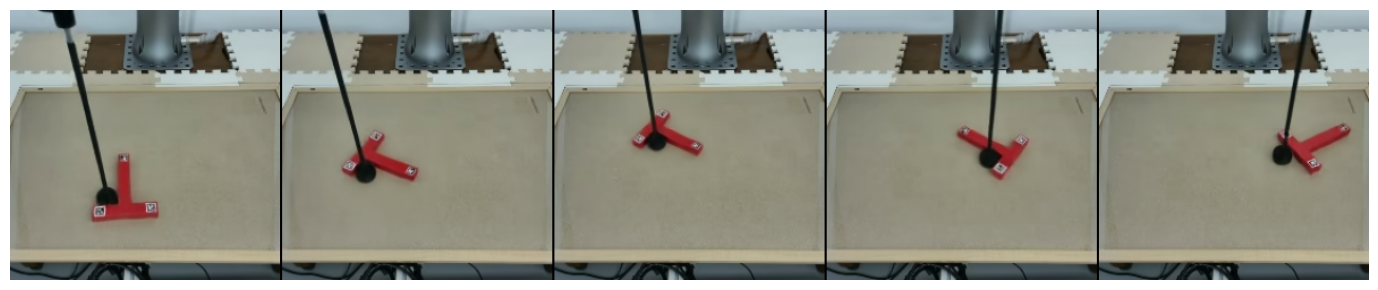

In [ ]:
from dreamerv4uwm.sampling import unified_video_sampler

num_diffusion_steps = 64
T_ctx = latents_ctx.shape[1]
T_total = 8

# Build a unified noisy latent: clean context + pure-noise horizon, then noise the whole thing to `current_tau`
l = torch.randn(1, T_total, *latents_ctx.shape[2:], device=latents_ctx.device, dtype=latents_ctx.dtype)
current_tau = 0.0  # starting noise level of the full (ctx + horizon) sequence

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_video = unified_video_sampler(
        denoiser,
        noisy_latents=l,
        current_tau=current_tau,
        n_act=cfg.denoiser.n_actions,
        num_diffusion_steps=num_diffusion_steps,
        use_shortcut=False,
    )
    with torch.no_grad():
        img_pred_video = tokenizer.decode(pred_obs_video)

plotVideo(img_pred_video[0].to(torch.float32))
plotSnapshots(img_pred_video[0].to(torch.float32))

## 5. Diffusion Forcing (`forcing`)
Given context obs + context actions (both conditioned with slight noise), jointly denoise future observations and actions. Both modalities are predicted for the future chunk.

In [ ]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_forc, pred_act_forc = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='forcing',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_forc = tokenizer.decode(pred_obs_forc)

plotVideo(img_pred_forc[0].to(torch.float32))
plotSnapshots(img_pred_forc[0].to(torch.float32))

# Plot predicted vs ground-truth actions
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_forc[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (forcing)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()

# Unified Shortcut Sampler — All 5 UWM Modes

The samplers below target the **shortcut** UWM denoiser (trained with `compute_bootstrap_uwm_loss`). Unlike the flow-matching samplers, which always use the finest step (`step_idx = 0 ↔ d_min`), the shortcut samplers set `step_idx = get_step_index(1/num_diffusion_steps, num_noise_levels)` so the denoiser takes a big dyadic step per Euler update.

Make sure `dynamics_ckpt` points to a shortcut-trained checkpoint (see cell above:
`checkpoints/dynamics/pushT/with-shortcuts/...`).


In [14]:
from dreamerv4uwm.sampling import unified_shortcut_sampler

num_pred_steps = 16
num_diffusion_steps = 8   # power of two; shortcut big-step
latents_ctx = latents[:, :4, ...].clone()
T_ctx = latents_ctx.shape[1]


## 1. World Model (`wm`) — shortcut
Given context obs and **all** actions, predict future observations using the shortcut big-step sampler.

In [15]:
all_actions_wm = actions[:T_ctx + num_pred_steps][None].clone()
all_actions_wm[:, T_ctx:, 0] = 0.0
all_actions_wm[:, T_ctx:, 1] = 0.0

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_wm_sc, _ = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='wm',
        all_actions=all_actions_wm,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_wm_sc = tokenizer.decode(pred_obs_wm_sc)

plotVideo(img_pred_wm_sc[0].to(torch.float32))
plotSnapshots(img_pred_wm_sc[0].to(torch.float32), n_frames=4)
plotActions(all_actions_wm[0, T_ctx:T_ctx+num_pred_steps])


This browser does not support the video tag.


NameError: name 'plotSnapshots' is not defined

## 2. Policy (`policy`) — shortcut
Given context obs + context actions, jointly predict future observations and future actions.

In [16]:
ctx_actions_policy = actions[:T_ctx][None].cuda()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_pol_sc, pred_act_pol_sc = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='policy',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_pol_sc = tokenizer.decode(pred_obs_pol_sc)

plotVideo(img_pred_pol_sc[0].to(torch.float32))
plotSnapshots(img_pred_pol_sc[0].to(torch.float32))
plotActions(pred_act_pol_sc[0].cpu().float().numpy())


This browser does not support the video tag.


NameError: name 'plotSnapshots' is not defined

## 3. Video Prediction (`video`) — shortcut
Given context obs only (actions are pure noise), predict future observations.

In [ ]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_vid_sc, _ = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='video',
        ctx_actions=ctx_actions_policy,  # only used to infer n_act
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_vid_sc = tokenizer.decode(pred_obs_vid_sc)

plotVideo(img_pred_vid_sc[0].to(torch.float32))
plotSnapshots(img_pred_vid_sc[0].to(torch.float32))


## 4. Inverse Dynamics (`id`) — shortcut
Given **all** observations (clean), predict actions across all frames.

In [ ]:
all_latents_id = latents[:, :T_ctx + num_pred_steps, ...]

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    _, pred_act_id_sc = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='id',
        ctx_actions=ctx_actions_policy,
        all_latents=all_latents_id,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_id_sc[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (inverse dynamics, shortcut)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()


## 5. Diffusion Forcing (`forcing`) — shortcut
Given context obs + context actions (both slightly noised), jointly denoise future obs and actions.

In [ ]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_forc_sc, pred_act_forc_sc = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='forcing',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_forc_sc = tokenizer.decode(pred_obs_forc_sc)

plotVideo(img_pred_forc_sc[0].to(torch.float32))
plotSnapshots(img_pred_forc_sc[0].to(torch.float32))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_forc_sc[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (forcing, shortcut)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()


# G1 Dataset — load & visualize

Smoke test for `G1ChunkDataset` against the chunked HDF5 layout at
`/scratch/rk4342/datasets/G1/wm/`. Pulls one window, decodes BGR→RGB images,
and plots the 22-dim `commands` vector (3 base vel + 17 upper-body joint
targets + 2 triggers) over time.

This cell is self-contained — no tokenizer or denoiser needed.

In [2]:
import mediapy
import matplotlib.pyplot as plt
import numpy as np
from dreamerv4uwm.datasets import G1ChunkDataset

G1_DATA_PATH = "/home/mim-server/robot/GR00T-WholeBodyControl/creo-g1-teleop/new_wm_h5_segmented_small/world_model"
g1_dataset = G1ChunkDataset(
    data_dir=G1_DATA_PATH,
    window_size=64,
    stride=1,
    split="train",
    train_fraction=0.9,
    split_seed=123,
)

stats = g1_dataset.get_episode_length_statistics()
print(f"chunks={len(g1_dataset.chunk_paths)}  episodes={stats['total_episodes']}  "
      f"frames={stats['total_timesteps']:,}  windows={len(g1_dataset):,}")
print(f"episode length: min={stats['min_length']} median={stats['median_length']:.0f} "
      f"max={stats['max_length']} mean={stats['mean_length']:.1f}")

sample = g1_dataset[len(g1_dataset) // 2]
imgs_g1 = sample["image"]      # (T, 3, H, W) RGB float in [0,1]
acts_g1 = sample["action"]     # (T, 22) float32
print(f"image: shape={tuple(imgs_g1.shape)} dtype={imgs_g1.dtype} "
      f"range=[{imgs_g1.min():.3f}, {imgs_g1.max():.3f}]")
print(f"action: shape={tuple(acts_g1.shape)} dtype={acts_g1.dtype}")

G1[train]: 520576 windows from 276 episodes (of 307 total) across 228 chunks
chunks=228  episodes=307  frames=593,329  windows=520,576
episode length: min=9 median=2600 max=2700 mean=1932.7
image: shape=(64, 3, 256, 256) dtype=torch.float32 range=[0.000, 1.000]
action: shape=(64, 22) dtype=torch.float32


This browser does not support the video tag.


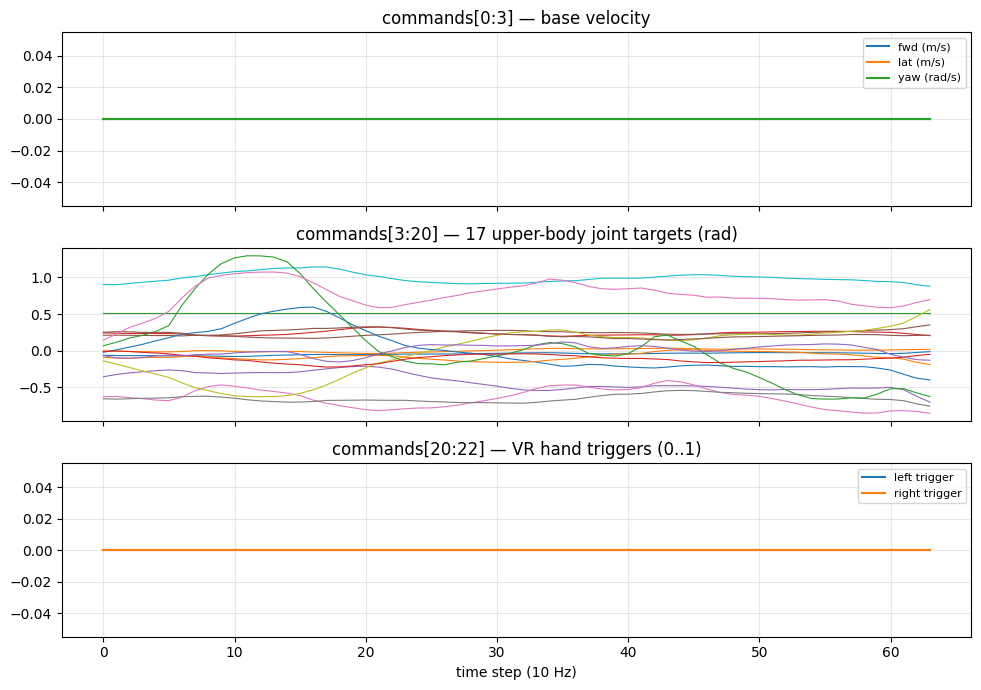

In [3]:
# Video preview (RGB → uint8 for mediapy)
imgs_np = (imgs_g1.permute(0, 2, 3, 1).numpy() * 255).clip(0, 255).astype(np.uint8)
mediapy.show_video(imgs_np, fps=10)

# 22-dim command vector over time, grouped by semantic block
acts_np = acts_g1.numpy()
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Block 1: base velocity commands (fwd, lat, yaw)
for i, name in enumerate(["fwd (m/s)", "lat (m/s)", "yaw (rad/s)"]):
    axes[0].plot(acts_np[:, i], label=name, linewidth=1.5)
axes[0].set_title("commands[0:3] — base velocity")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Block 2: 17 upper-body joint targets (planner permuted order)
for i in range(3, 20):
    axes[1].plot(acts_np[:, i], linewidth=0.8)
axes[1].set_title("commands[3:20] — 17 upper-body joint targets (rad)")
axes[1].grid(True, alpha=0.3)

# Block 3: hand triggers
axes[2].plot(acts_np[:, 20], label="left trigger", linewidth=1.5)
axes[2].plot(acts_np[:, 21], label="right trigger", linewidth=1.5)
axes[2].set_title("commands[20:22] — VR hand triggers (0..1)")
axes[2].set_xlabel("time step (10 Hz)")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt

def plotSnapshots(video, n_frames=5, border_width=2, figsize=None, save_path=None):
    """Plot n_frames evenly-spaced snapshots from a video tensor, separated by black borders.
    
    Args:
        video: (T, C, H, W) tensor with values in [0, 1].
        n_frames: number of frames to sample.
        border_width: width of black separator lines in pixels.
    """
    import numpy as np
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()  # (n, H, W, C)
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, W, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    if figsize is None:
        figsize = (n_frames * 3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip)
    ax.axis('off')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.show()


In [21]:
cfg.tokenizer_ckpt_format

'reference'

In [22]:
tokenizer_ckpt="/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/g1_reference.pt"
cfg.tokenizer_ckpt=tokenizer_ckpt
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300)
tokenizer = tokenizer.eval().cuda()

This browser does not support the video tag.


This browser does not support the video tag.


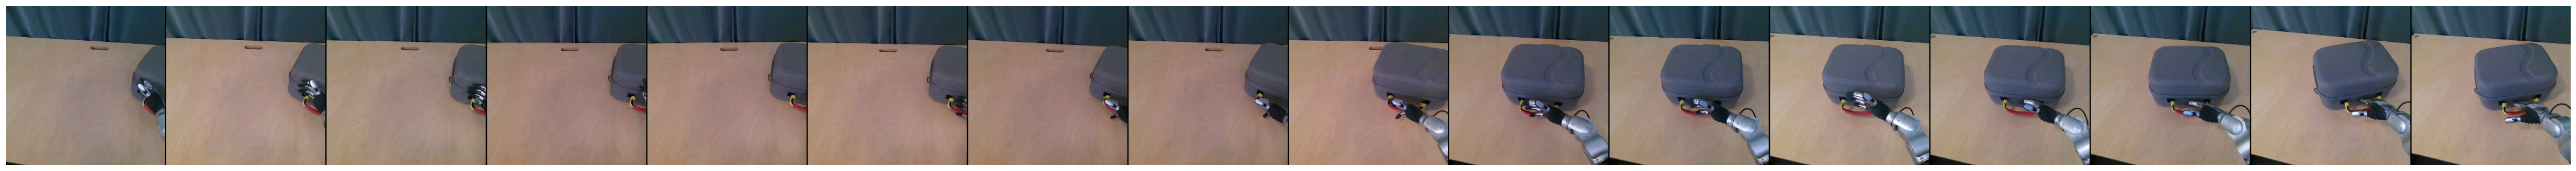

In [25]:
from torch.nn.functional import interpolate
imgs = sample["image"] 
imgs = interpolate(imgs, resolution).to(device=device)[None] # resize to tokenizer resolution

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        latents = tokenizer.encode(imgs)
        imgs_recon = tokenizer.decode(latents)

from mediapy import show_video
def plotVideo(video):
    imgs = video.cpu().permute(0,2,3,1).to(torch.float32).numpy()*255
    imgs = imgs.astype('uint8')
    mediapy.show_video(imgs, fps=10)

plotVideo(imgs_recon[0])
plotVideo(imgs[0])
plotSnapshots(imgs_recon[0].to(torch.float32), n_frames=16, save_path="results/1.png")

## Multi-stream tokenizer (reference G1 checkpoint)

Loads the **two-stream** tokenizer port (`MultiStreamTokenizerWrapper`) with the
pretrained G1 reference checkpoint at `/home/mim-server/robot/GR00T-WholeBodyControl/tokenizer.pt`
via `load_tokenizer(..., ckpt_format="reference")` and runs encode/decode on
the same kind of G1 frames as the cell above. The reference was trained with
proprio (`proprio_dim=50`), which `G1ChunkDataset` doesn't surface, so this
cell pulls (images, proprio) directly from one local H5 chunk.

In [ ]:
import h5py
import torch
from omegaconf import OmegaConf

from dreamerv4uwm.models.utils import load_tokenizer

REF_TOKENIZER_CKPT = "/home/mim-server/robot/GR00T-WholeBodyControl/tokenizer.pt"
G1_LOCAL_H5 = ("/home/mim-server/robot/GR00T-WholeBodyControl/creo-g1-teleop/"
               "new_wm_h5_segmented_small/world_model/chunk_0000.h5")
WIN_START, WIN_LEN = 200, 64

# Architecture matches wm_pico_eval_kvcache.py constants for the G1 reference.
ms_cfg = OmegaConf.create({
    "tokenizer": {
        "architecture": "multi_stream",
        "num_modality_tokens": 256,
        "num_latent_tokens": 256,
        "max_sequence_length": 5000,
        "context_length": 32,
        "model_dim": 1024,
        "latent_dim": 32,
        "enc_num_layers": 16,
        "dec_num_layers": 16,
        "n_heads": 16,
        "n_kv_heads": 16,
        "dropout_prob": 0.0,
        "qk_norm": False,
        "patch_size": 16,
        "multi_stream": {
            "mlp_ratio": 4.0,
            "temporal_every": 4,
            "mae_max_mask_prob": 0.0,
            "activate_masking": False,
            "use_proprio": True,
            "proprio_dim": 50,
            "num_proprio": 1,
            "in_channels": 3,
        },
    },
    "dataset": {"resolution": [256, 256]},
    "tokenizer_ckpt": REF_TOKENIZER_CKPT,
})

ms_tokenizer = load_tokenizer(
    ms_cfg, device=device,
    max_num_forward_steps=ms_cfg.tokenizer.max_sequence_length,
    ckpt_format="reference",
).to(dtype=torch.bfloat16).eval()
print(f"loaded multi-stream tokenizer: "
      f"{sum(p.numel() for p in ms_tokenizer.parameters()) / 1e6:.0f}M params")

# G1ChunkDataset doesn't return proprio, so pull (images, proprio) from H5.
with h5py.File(G1_LOCAL_H5, "r") as f:
    imgs_bgr = f["images"][WIN_START:WIN_START + WIN_LEN]      # (T, 256, 256, 3) uint8 BGR
    proprio_np = f["proprio"][WIN_START:WIN_START + WIN_LEN]    # (T, 50) float32

imgs_ms = torch.from_numpy(imgs_bgr[..., ::-1].copy()).float().div_(255.0).permute(0, 3, 1, 2)
imgs_ms = imgs_ms.to(device=device, dtype=torch.bfloat16).unsqueeze(0)        # (1, T, 3, H, W)
proprio_ms = torch.from_numpy(proprio_np).to(device=device, dtype=torch.bfloat16).unsqueeze(0)

with torch.no_grad():
    z_ms = ms_tokenizer.encode(imgs_ms, proprio=proprio_ms)
    imgs_recon_ms = ms_tokenizer.decode(z_ms)

mse = (imgs_recon_ms.float() - imgs_ms.float()).pow(2).mean().item()
print(f"latents: {tuple(z_ms.shape)}  recon MSE: {mse:.5f}")

plotVideo(imgs_recon_ms[0])
plotVideo(imgs_ms[0].to(torch.float32))
plotSnapshots(imgs_recon_ms[0].to(torch.float32), n_frames=16)

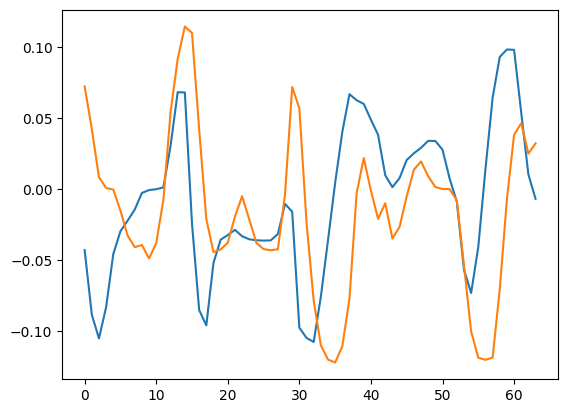

In [8]:
import matplotlib.pyplot as plt
# plot actions 
plt.plot(actions.cpu().numpy())

In [105]:
latents_ctx_noisy.shape

torch.Size([1, 4, 256, 32])

# Autoregressive Sampling — `AutoRegressiveForwardDynamics`

KV-cached, frame-by-frame rollout for the **flow-matching** UWM denoiser. The class wraps the denoiser and tokenizer together with their decoder caches and supports two modes:

- **`wm`** — world model. The caller passes the next action at every `step()`; the action is treated as clean and only the next observation is denoised.
- **`policy`** — `step()` takes no input; the next observation and the next action are denoised jointly. Context actions are slightly noised at `tau_cond` to match policy training.

Both modes prime the cache via `reset(imgs_init, actions_init)` and then advance one frame per `step()`.


In [19]:
from dreamerv4uwm.sampling import AutoRegressiveForwardDynamics
episode_length = 128
demo_end_index = 3
num_pred_steps = episode_length - demo_end_index
T_ctx = demo_end_index

denoising_step_count = 16        # power of two; flow-matching Euler steps per frame
context_cond_tau = 0.99
# max_forward_steps = T_ctx + num_pred_steps + 4   # safety margin for KV cache size
max_forward_steps = 64   # safety margin for KV cache size

imgs_ctx = imgs[:, :T_ctx]                      # (1, T_ctx, C, H, W)
actions_ctx = actions[:T_ctx][None].to(device)  # (1, T_ctx, n_act)

N_batch = 4
imgs_ctx = imgs_ctx.expand(N_batch, -1, -1, -1, -1)
actions_ctx = actions_ctx.expand(N_batch, -1, -1)

## 1. World-model rollout (`mode='wm'`)
We supply the next action at every step — actions are treated as clean and only the next obs is denoised. We feed the ground-truth future actions for the visualisation.


In [20]:
ar_wm = AutoRegressiveForwardDynamics(
    denoiser=denoiser,
    tokenizer=tokenizer,
    mode='wm',
    context_length=max_forward_steps,
    max_forward_steps=max_forward_steps,
    context_cond_tau=context_cond_tau,
    denoising_step_count=denoising_step_count,
    device=device,
    dtype=torch.float32,
)

future_actions_wm = torch.zeros(1, num_pred_steps, actions_ctx.shape[-1], device=device)  # (1, T_pred, n_act)
future_actions_wm = future_actions_wm * 0.0   # zero-action rollout for visualisation
future_actions_wm[:, :, 0] = -0.00
future_actions_wm[:, :, 1] = 0.0
frames_wm = []
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    ar_wm.reset(imgs_ctx, actions_ctx)
    for t in range(num_pred_steps):
        img_t = ar_wm.step(actions_t=future_actions_wm[:, t])
        frames_wm.append(img_t.detach().cpu())

video_wm = torch.stack(frames_wm, dim=1)[0]      # (num_pred_steps, C, H, W)
plotVideo(video_wm.to(torch.float32))
plotSnapshots(video_wm.to(torch.float32), n_frames=5)
plotActions(future_actions_wm[0])


RuntimeError: Sizes of tensors must match except in dimension 2. Expected size 4 but got size 1 for tensor number 4 in the list.

## 2. Policy rollout (`mode='policy'`)
No actions are fed during rollout — the policy denoises the next obs and the next action jointly at each step.


In [21]:
ar_pol = AutoRegressiveForwardDynamics(
    denoiser=denoiser,
    tokenizer=tokenizer,
    mode='policy',
    context_length=max_forward_steps,
    max_forward_steps=max_forward_steps,
    context_cond_tau=context_cond_tau,
    denoising_step_count=denoising_step_count,
    device=device,
    dtype=torch.float32,
)



In [22]:
frames_pol, acts_pol = [], []
with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        ar_pol.reset(imgs_ctx, actions_ctx)
        for t in range(num_pred_steps):
            img_t, act_t = ar_pol.step()
            frames_pol.append(img_t.detach().cpu())
            acts_pol.append(act_t.detach().cpu())

In [23]:
video_pol = torch.stack(frames_pol, dim=1)
acts_pol_seq = torch.stack(acts_pol, dim=1)

video_all = torch.concat([imgs[:, :T_ctx].cpu().expand(video_pol.shape[0], -1, -1, -1, -1), video_pol.cpu()], dim=1)  # (1, 3, T, C, H, W)
# actions_all = torch.concat([actions[:T_ctx].cpu(), acts_pol_seq.cpu()], dim=0)  # (1, T, n_act)
for k in range(video_all.shape[0]):
    plotVideo(video_all.to(torch.float32)[k])

# plotSnapshots(video_all.to(torch.float32), n_frames=5)
# plotActions(acts_pol_seq.to(torch.float32))

This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.
